# FIP 04 — DA × NE cross-correlation and coherence across animals

`fip_03_da_ne_commonality.ipynb` §3–§3b measured the DA × NE relationship in the 10 sessions that
have motion energy, all from one animal (808054). Its cross-correlation peaked at lag 0.00 in 9 of
10 sessions (median peak r = 0.29), and its coherence was a band-limited peak at 0.12–0.45 Hz
(2–8 s timescales). Neither measurement needs motion energy, so this notebook runs both over every
curated session that has a matched DA/NE pair and makes **animal** the unit of inference.

**"NE"**: PL-GCaMP, GCaMP in LC noradrenergic axons (FLEX GCaMP in LC of DBH-Cre mice) imaged at a
prelimbic fiber. **"DA"**: NAc dLight.

**Hemisphere matching.** Every pair is DA and NE from the same side: `PL(L)-Gcamp` with
`NAc(L)-dLight`, or `PL(R)-Gcamp` with `NAc(R)-dLight`. Curation drops each animal's noisy PL fiber,
so most animals have one usable side. An animal that has both is held to the side with more
sessions, so every animal contributes one hemisphere throughout. Which side that is differs between
animals.

**Sampling unit.** Sessions are averaged within an animal first, then across animals. Error bars
on grand means are SEM over animals, and the across-animal tests are Wilcoxon signed-rank on
animal means. With n animals the smallest attainable two-sided p is 2 / 2ⁿ (0.016 for 7).

**Sign convention.** `fu.norm_xcorr(da, ne)` puts a peak at positive lag when **NE leads DA**,
the convention `fip_02` and `fip_03` use.

Runtime after `load_curated_sessions()`: roughly 10 minutes, most of it the coherence null.

## 1. Imports & setup

`fip_utils` supplies loading, curation, the signal inventory (`build_meta`), `get_trace`, `zscore`
and `norm_xcorr`. Everything else is notebook-local.

In [1]:
import gc
import os
import pickle
import re
import time
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy import stats, signal

# autoreload so editing fip_utils.py doesn't cost a kernel restart + a full session reload.
%load_ext autoreload
%autoreload 2
import fip_utils as fu

from plotstyle import apply_style, PALETTE, OKABE_ITO, style_ax, save_fig

%matplotlib inline
apply_style()

In [2]:
# ── Grid and session inclusion ────────────────────────────────────────────────
FS = 20                    # Hz, common grid for both signals
TASK_PAD_S = 10.0          # s kept after the last go cue; the grid starts at the first go cue
MIN_DURATION_S = 600.0     # s, shorter matched pairs are skipped
MAX_NONFINITE = 0.05       # skip a pair when either trace has more than this fraction non-finite
MIN_SESSIONS_PER_ANIMAL = 3
HEMI_BY_SUBJECT = {}       # override the per-animal side, e.g. {"808054": "R"}

# ── Cross-correlation and coherence ───────────────────────────────────────────
MAXLAG = 3.0               # s
N_SHIFT = 200              # circular shifts per session; p-value floor 1/(N_SHIFT+1)
MIN_SHIFT_S = 60.0         # s, smallest circular shift -- well past the 2-8 s shared timescale
COH_NPERSEG = 1024         # 51.2 s segments -> 0.02 Hz resolution
CLUSTER_ALPHA = 0.05
BAND_HZ = (0.12, 0.45)     # fip_03's coherence cluster, fixed in advance here (see section 4)

# ── Summaries ─────────────────────────────────────────────────────────────────
WIN_S, WIN_STEP_S = 120.0, 60.0   # windowed zero-lag correlation across the session
WIN_MAX_S = 7200.0
MIN_ANIMALS_PER_WINDOW = 3
N_BOOT = 10000             # hierarchical bootstrap: animals, then sessions within animal
SEED = 0

# ── Example session (None = the session whose peak r sits closest to the median) ──
EXAMPLE_SESSION = None
EXAMPLE_WINDOW_S = 180.0   # s of trace in panel a
EXAMPLE_ZOOM_S = 20.0      # s of trace in panel b, centred in panel a's window

# ── Output ────────────────────────────────────────────────────────────────────
FIG_DIR = "/root/capsule/scratch/figures/fip"  # note: /scratch is not kept by a reproducible run
SAVE_FIG = True

DA_COLOR, NE_COLOR, GRAND_COLOR = PALETTE["pos"], PALETTE["neg"], PALETTE["all"]
NULL_COLOR, SIG_COLOR = PALETTE["not_sig"], PALETTE["sig"]
DA_LABEL, NE_LABEL = "DA (NAc dLight)", "NE (PL-GCaMP)"
LAG_XLABEL = "lag (s)   —   positive = NE leads DA"

# Per-animal identity: Okabe-Ito in fixed order, yellow and black left out (yellow fails contrast
# on white; black is the grand-mean colour). Marker shape repeats the identity, so colour is
# never the only cue.
ANIMAL_HUES = [OKABE_ITO[k] for k in ("orange", "sky_blue", "bluish_green", "blue",
                                      "vermillion", "reddish_purple")]
ANIMAL_MARKERS = ["o", "s", "^", "D", "v", "P", "X", "h"]

rng = np.random.default_rng(SEED)
K_LAG = int(round(MAXLAG * FS))
LAG_IDX = np.arange(-K_LAG, K_LAG + 1)
LAGS = LAG_IDX / float(FS)
MIN_SHIFT = int(round(MIN_SHIFT_S * FS))

## 2. Load and pair DA with NE by hemisphere

Region labels come from curation (`intended_measurement`, surfaced as `meta["region"]` by
`fu.build_meta`) and look like `NAc(L)-dLight` and `PL(R)-Gcamp`. `matched_pairs` reads the side
out of the parentheses and keeps each side that carries both a NAc dLight and a PL GCaMP label.

Each pair is cut to the task (first go cue to last go cue + `TASK_PAD_S`), non-finite samples are
dropped, and both traces are interpolated onto one `FS`-Hz grid. Both channels come from the same
`df_fip`, acquisition and upstream dF/F (`dff-bright_mc-iso-IRLS`), so the only difference in their
filtering is sensor kinetics — `fip_03` §2 measured that.

In [3]:
HEMI_RE = re.compile(r"\((L|R)\)")


def hemisphere(region):
    # 'NAc(L)-dLight' -> 'L'; None when the label carries no side.
    m = HEMI_RE.search(region or "")
    return m.group(1) if m else None


def matched_pairs(meta):
    '''Same-side (DA, NE) region labels in one session.

    Parameters
    ----------
    meta : pandas.DataFrame
        From ``fu.build_meta``; must carry ``region``.

    Returns
    -------
    dict
        ``{side: (da_region, ne_region)}`` for each side with both a NAc dLight and a PL GCaMP.
    '''
    regions = [r for r in meta["region"].dropna().unique()]
    da = {hemisphere(r): r for r in regions
          if r.lower().startswith("nac") and "dlight" in r.lower()}
    ne = {hemisphere(r): r for r in regions
          if r.lower().startswith("pl") and "gcamp" in r.lower()}
    return {h: (da[h], ne[h]) for h in sorted(set(da) & set(ne)) if h is not None}


def best_event(meta, df_fip, region, prefer_variant="dff"):
    '''The df_fip event carrying exactly this region label.

    ``fu.pick_example``'s rule -- prefer a dff variant, then the most finite samples -- with an
    exact label match, because a substring such as ``'dLight'`` would match both sides.
    '''
    cand = meta[meta["region"] == region]
    pref = cand[cand["variant"].str.contains(prefer_variant, case=False, regex=False)]
    pool = pref if not pref.empty else cand
    return max(pool["event"],
               key=lambda ev: int(np.isfinite(fu.get_trace(df_fip, ev)[1]).sum()))


def finite_trace(df_fip, event):
    # (t, y, fraction of samples dropped as non-finite)
    t, y = fu.get_trace(df_fip, event, data_col="data")
    ok = np.isfinite(t) & np.isfinite(y)
    return t[ok], y[ok], 1.0 - ok.mean() if len(ok) else 1.0

In [4]:
# Loading the NWB list costs tens of GB and several minutes. The cache keeps only what later
# sections read: one float32 trace per signal per matched pair, the grid start, the go cues and
# the labels -- roughly 1 MB per pair. Set REBUILD = True after changing anything in the
# "Grid and session inclusion" block above.
CACHE = "/root/capsule/scratch/fip_04_pairs.pkl"
REBUILD = False

USE_CACHE = not REBUILD and os.path.exists(CACHE)
if USE_CACHE:
    print("cache written %s -- set REBUILD = True to reload from the NWB list"
          % time.ctime(os.path.getmtime(CACHE)))
else:
    nwb_list = fu.load_curated_sessions()

plot_loc = /root/capsule/data/DA_NE_4channels/
loading 7 df_sess file(s)
no bg_coef files found at plot location, skipping
no rpe_slope.csv found at plot location, skipping
loading 808054_2025-09-02
loading 808054_2025-09-03
loading 808054_2025-09-04
loading 808054_2025-09-05
loading 808054_2025-09-08
loading 808054_2025-09-09
loading 808054_2025-09-10
loading 808054_2025-09-11
loading 808054_2025-09-12
loading 808054_2025-09-15
loading 808054_2025-09-16
loading 808054_2025-09-17
loading 808054_2025-09-18
loading 808054_2025-09-19
loading 808054_2025-09-22
loading 808054_2025-09-23
loading 808054_2025-09-24
loading 808054_2025-09-25
loading 808054_2025-09-26
loading 808054_2025-10-02
loading 808054_2025-10-07
loading 808054_2025-10-08
loading 808054_2025-10-10
loading 808054_2025-10-13
loading 808054_2025-10-14
loading 808054_2025-10-15
loading 808054_2025-10-16
loading 808054_2025-10-17
loading 808056_2025-09-12
loading 808056_2025-09-15
loading 808056_2025-09-16
loading 808056_2025-0

In [5]:
if USE_CACHE:
    records = pickle.load(open(CACHE, "rb"))
    print("loaded %d matched pairs from cache" % len(records))
else:
    records = []
    skipped = Counter()
    for nwb in nwb_list:
        df_fip = nwb.df_fip
        df_trials = getattr(nwb, "df_trials", None)
        if df_trials is None or fu.ALIGN_COL not in df_trials.columns:
            skipped["no df_trials"] += 1
            continue
        go = df_trials[fu.ALIGN_COL].dropna().to_numpy(float)
        if len(go) < 2:
            skipped["no go cues"] += 1
            continue

        meta = fu.build_meta(df_fip)
        if "region" not in meta.columns:
            skipped["no region labels"] += 1
            continue
        pairs = matched_pairs(meta)
        if not pairs:
            skipped["no same-side DA/NE pair"] += 1
            continue

        for side, (da_region, ne_region) in pairs.items():
            da_event = best_event(meta, df_fip, da_region)
            ne_event = best_event(meta, df_fip, ne_region)
            t_da, da, bad_da = finite_trace(df_fip, da_event)
            t_ne, ne, bad_ne = finite_trace(df_fip, ne_event)
            if max(bad_da, bad_ne) > MAX_NONFINITE:
                skipped["too many non-finite samples"] += 1
                continue

            lo = max(t_da.min(), t_ne.min(), go.min())
            hi = min(t_da.max(), t_ne.max(), go.max() + TASK_PAD_S)
            if hi - lo < MIN_DURATION_S:
                skipped["shorter than MIN_DURATION_S"] += 1
                continue

            grid = np.arange(lo, hi, 1.0 / FS)
            records.append({
                "session_id": nwb.session_id,
                "subject_id": nwb.session_id.split("_")[0],
                "hemi": side, "da_region": da_region, "ne_region": ne_region,
                "da_event": da_event, "ne_event": ne_event,
                "t0": float(grid[0]),
                "da": np.interp(grid, t_da, da).astype(np.float32),
                "ne": np.interp(grid, t_ne, ne).astype(np.float32),
                "go_cues": go[(go >= grid[0]) & (go <= grid[-1])],
            })

    os.makedirs(os.path.dirname(CACHE), exist_ok=True)
    pickle.dump(records, open(CACHE, "wb"), protocol=4)
    print("%d sessions in nwb_list -> %d matched pairs cached -> %s"
          % (len(nwb_list), len(records), CACHE))
    print("skipped: %s" % dict(skipped))

    # Nothing below reads nwb_list; releasing it frees tens of GB.
    del nwb_list
    gc.collect()

172 sessions in nwb_list -> 144 matched pairs cached -> /root/capsule/scratch/fip_04_pairs.pkl
skipped: {'no same-side DA/NE pair': 28}


### One side per animal

The table counts matched pairs per animal and side. `side` is the one each animal contributes:
its side with more sessions, or the `HEMI_BY_SUBJECT` override. Animals with fewer than
`MIN_SESSIONS_PER_ANIMAL` sessions on that side are dropped.

In [6]:
avail = pd.DataFrame([{"subject": r["subject_id"], "session": r["session_id"], "hemi": r["hemi"]}
                      for r in records])
by_side = (avail.pivot_table(index="subject", columns="hemi", values="session",
                             aggfunc="count", fill_value=0)
           .reindex(columns=["L", "R"], fill_value=0))
by_side["side"] = [HEMI_BY_SUBJECT.get(subj, row[["L", "R"]].astype(int).idxmax())
                   for subj, row in by_side.iterrows()]
by_side["n_used"] = [int(row[row["side"]]) for _, row in by_side.iterrows()]
by_side["kept"] = by_side["n_used"] >= MIN_SESSIONS_PER_ANIMAL

SIDE = by_side.loc[by_side["kept"], "side"].to_dict()
sessions = [dict(r) for r in records if SIDE.get(r["subject_id"]) == r["hemi"]]
sessions.sort(key=lambda s: (s["subject_id"], s["session_id"]))
for s in sessions:
    s["da"] = fu.zscore(s["da"].astype(float))
    s["ne"] = fu.zscore(s["ne"].astype(float))
    s["t"] = s["t0"] + np.arange(len(s["da"])) / float(FS)

SUBJECTS = sorted(SIDE)
N_ANIMALS = len(SUBJECTS)
SUBJ_IDX = np.array([SUBJECTS.index(s["subject_id"]) for s in sessions])
# Hue and marker cycle independently (6 x 8), so each pair is unique up to 24 animals.
ANIMAL_STYLE = {subj: (ANIMAL_HUES[i % len(ANIMAL_HUES)], ANIMAL_MARKERS[i % len(ANIMAL_MARKERS)])
                for i, subj in enumerate(SUBJECTS)}

print(by_side.to_string())
print("\n%d sessions from %d animals | sides: %s"
      % (len(sessions), N_ANIMALS, dict(Counter(SIDE.values()))))
print("median session length %.1f min"
      % (np.median([len(s["da"]) for s in sessions]) / FS / 60.0))

hemi      L   R side  n_used  kept
subject                           
808054    0  28    R      28  True
808056    0  40    R      40  True
809491   29   0    L      29  True
816212   27   0    L      27  True
816214   20   0    L      20  True

144 sessions from 5 animals | sides: {'R': 2, 'L': 3}
median session length 74.9 min


### Averaging over animals

Every grand mean below is a mean of per-animal means, so an animal with 30 sessions weighs the
same as one with 3.

In [7]:
def animal_means(values):
    '''Average per-session values within each animal.

    Parameters
    ----------
    values : array_like
        ``(n_sessions, ...)`` in ``sessions`` order.

    Returns
    -------
    numpy.ndarray
        ``(n_animals, ...)`` in ``SUBJECTS`` order.
    '''
    values = np.asarray(values, float)
    with warnings.catch_warnings():   # all-NaN columns are expected (section 7's late windows)
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return np.stack([np.nanmean(values[SUBJ_IDX == i], axis=0) for i in range(N_ANIMALS)])


def grand_mean(values):
    '''Mean and SEM over animals of per-animal means; also returns the per-animal means.'''
    am = animal_means(values)
    n = np.sum(np.isfinite(am), axis=0)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        sem = np.nanstd(am, axis=0, ddof=1) / np.sqrt(np.maximum(n, 1))
        return np.nanmean(am, axis=0), sem, am


def hier_boot_mean(values, n_boot=N_BOOT):
    '''Hierarchical bootstrap of the grand mean: resample animals, then sessions within each.'''
    values = np.asarray(values, float)
    groups = [values[SUBJ_IDX == i] for i in range(N_ANIMALS)]
    out = np.empty(n_boot)
    for b in range(n_boot):
        pick = rng.integers(0, N_ANIMALS, N_ANIMALS)
        out[b] = np.mean([rng.choice(groups[j], len(groups[j])).mean() for j in pick])
    return out

## 3. Cross-correlation per session

The observed curve is `fu.norm_xcorr(da, ne)` on the task-period grid. The null circularly shifts
NE against DA by at least `MIN_SHIFT_S`, which keeps each trace's own autocorrelation and removes
only their alignment.

A circular shift of NE by `k` samples followed by a lag of `L` gives the same products as the
circular cross-correlation at `k + L`, so one FFT supplies all `N_SHIFT` null curves. The null is
therefore circular while the observed curve is linear; they differ only in the `|L|` samples that
wrap around, at most `MAXLAG` s out of a session of tens of minutes.

Per session: peak r (signed, at the largest |r| within ±`MAXLAG`), its lag, zero-lag r, the
median of the null's peak |r|, and a shift p-value on peak |r|.

In [8]:
def circular_xcorr(a, b):
    '''Circular normalised cross-correlation at every shift, via FFT.

    ``out[k] = mean_t(a[t + k] * b[t])`` (indices mod n) with ``a``, ``b`` z-scored, so index
    ``k`` matches ``fu.norm_xcorr``'s lag ``k``: positive k means b leads a.
    '''
    a = np.asarray(a, float)
    b = np.asarray(b, float)
    a = (a - a.mean()) / a.std()
    b = (b - b.mean()) / b.std()
    n = len(a)
    return np.fft.irfft(np.fft.rfft(a) * np.conj(np.fft.rfft(b)), n) / n


t_start = time.time()
for s in sessions:
    lags, cc = fu.norm_xcorr(s["da"], s["ne"], fs=FS, maxlag=MAXLAG)
    circ = circular_xcorr(s["da"], s["ne"])
    n = len(circ)
    shifts = rng.integers(MIN_SHIFT, n - MIN_SHIFT, size=N_SHIFT)
    null_cc = circ[(shifts[:, None] + LAG_IDX[None, :]) % n]      # (N_SHIFT, n_lags)

    k = int(np.argmax(np.abs(cc)))
    null_peaks = np.max(np.abs(null_cc), axis=1)
    s["xcorr"], s["xcorr_null"] = cc, null_cc
    s["peak_r"], s["peak_lag"] = float(cc[k]), float(lags[k])
    s["r0"] = float(cc[K_LAG])
    s["peak_null_median"] = float(np.median(null_peaks))
    s["peak_p"] = (1 + int(np.sum(null_peaks >= abs(cc[k])))) / (1.0 + N_SHIFT)
print("cross-correlation: %d sessions in %.0f s" % (len(sessions), time.time() - t_start))

df_sess = pd.DataFrame([{
    "subject": s["subject_id"], "session": s["session_id"], "side": s["hemi"],
    "minutes": len(s["da"]) / FS / 60.0,
    "peak_r": s["peak_r"], "peak_lag_s": s["peak_lag"], "r0": s["r0"],
    "null_median": s["peak_null_median"], "p_shift": s["peak_p"]} for s in sessions])
print("sessions above their own null at p<0.05: %d / %d"
      % (int((df_sess["p_shift"] < 0.05).sum()), len(df_sess)))
print("sessions peaking at exactly lag 0: %d / %d"
      % (int((df_sess["peak_lag_s"] == 0).sum()), len(df_sess)))

cross-correlation: 144 sessions in 10 s
sessions above their own null at p<0.05: 142 / 144
sessions peaking at exactly lag 0: 48 / 144


## 4. Coherence per session

Magnitude-squared coherence (Welch, `COH_NPERSEG` = 51.2 s segments) with the same circular-shift
null, one `signal.coherence` call per shift. Significance uses `fip_03` §3b's cluster test:
contiguous frequency runs above the null's 95th percentile are scored by their area above it and
compared with the largest cluster the null produces anywhere in the spectrum. The test is biased
toward broad effects; a narrowband coupling would be rejected for its width.

`BAND_HZ` is the cluster `fip_03` found in 808054 and is fixed here before looking at the other
animals. Mean coherence inside it gives one number per session. 808054 is in this dataset too, so
for that animal the band is not an independent choice.

In [9]:
def contiguous_runs(mask):
    '''[(start, end)] index pairs for each contiguous True run in a boolean mask.'''
    out, i, n = [], 0, len(mask)
    while i < n:
        if mask[i]:
            j = i
            while j + 1 < n and mask[j + 1]:
                j += 1
            out.append((i, j))
            i = j + 1
        else:
            i += 1
    return out


def cluster_test(obs, null, freqs, alpha=CLUSTER_ALPHA):
    '''Cluster-mass permutation test on a spectrum (fip_03 section 3b).

    Parameters
    ----------
    obs : numpy.ndarray
        Observed spectrum, ``(n_freq,)``.
    null : numpy.ndarray
        Null spectra, ``(n_null, n_freq)``, drawn the same way as ``obs``.
    freqs : numpy.ndarray
        Frequency of each bin.
    alpha : float
        Cluster-level significance.

    Returns
    -------
    tuple
        ``(clusters, threshold, critical_mass)`` -- ``clusters`` is a list of dicts for the
        clusters whose mass exceeds the critical mass.
    '''
    thr = np.percentile(null, 95, axis=0)
    null_max = np.empty(len(null))
    for i, nl in enumerate(null):
        masses = [float(np.sum(nl[a:b + 1] - thr[a:b + 1])) for a, b in contiguous_runs(nl > thr)]
        null_max[i] = max(masses) if masses else 0.0
    crit = float(np.percentile(null_max, 100 * (1 - alpha)))
    found = []
    for a, b in contiguous_runs(obs > thr):
        mass = float(np.sum(obs[a:b + 1] - thr[a:b + 1]))
        if mass > crit:
            j = a + int(np.argmax(obs[a:b + 1]))
            found.append({"lo_Hz": freqs[a], "hi_Hz": freqs[b], "n_bins": b - a + 1,
                          "peak_coh": float(obs[j]), "peak_Hz": float(freqs[j]), "mass": mass,
                          "p": (1 + int(np.sum(null_max >= mass))) / (1.0 + len(null))})
    return found, thr, crit


t_start = time.time()
for s in sessions:
    f_coh, cxy = signal.coherence(s["da"], s["ne"], fs=FS, nperseg=COH_NPERSEG)
    n = len(s["ne"])
    shifts = rng.integers(MIN_SHIFT, n - MIN_SHIFT, size=N_SHIFT)
    nl = np.empty((N_SHIFT, len(f_coh)), np.float32)
    for i, sh in enumerate(shifts):
        nl[i] = signal.coherence(s["da"], np.roll(s["ne"], sh), fs=FS, nperseg=COH_NPERSEG)[1]
    s["coh"], s["coh_null"] = cxy, nl
print("coherence: %d sessions x %d shifts in %.0f s"
      % (len(sessions), N_SHIFT, time.time() - t_start))

IN_BAND = (f_coh >= BAND_HZ[0]) & (f_coh <= BAND_HZ[1])
for s in sessions:
    band_null = s["coh_null"][:, IN_BAND].mean(axis=1)
    s["band_coh"] = float(s["coh"][IN_BAND].mean())
    s["band_null_median"] = float(np.median(band_null))
    s["band_p"] = (1 + int(np.sum(band_null >= s["band_coh"]))) / (1.0 + N_SHIFT)

df_sess["band_coh"] = [s["band_coh"] for s in sessions]
df_sess["band_null_median"] = [s["band_null_median"] for s in sessions]
df_sess["band_p"] = [s["band_p"] for s in sessions]
print("sessions with %.2f-%.2f Hz coherence above their own null at p<0.05: %d / %d"
      % (BAND_HZ[0], BAND_HZ[1], int((df_sess["band_p"] < 0.05).sum()), len(df_sess)))

coherence: 144 sessions x 200 shifts in 242 s
sessions with 0.12-0.45 Hz coherence above their own null at p<0.05: 144 / 144


## 5. Grand means and animal-level tests

The grand-mean null is built the same way as the grand mean: null draw `i` from every session is
averaged within animal, then across animals. Draws with the same index come from independent
random shifts, so each averaged draw is one sample of the grand mean under the null.

In [10]:
# Cross-correlation
xc_mean, xc_sem, xc_animal = grand_mean([s["xcorr"] for s in sessions])
xc_null = animal_means(np.stack([s["xcorr_null"] for s in sessions])).mean(axis=0)  # (N_SHIFT, n_lags)
xc_null_lo, xc_null_hi = np.percentile(xc_null, [2.5, 97.5], axis=0)
k_grand = int(np.argmax(np.abs(xc_mean)))
grand_null_peaks = np.max(np.abs(xc_null), axis=1)
grand_peak_p = (1 + int(np.sum(grand_null_peaks >= abs(xc_mean[k_grand])))) / (1.0 + N_SHIFT)

# Coherence
coh_mean, coh_sem, coh_animal = grand_mean([s["coh"] for s in sessions])
coh_null = animal_means(np.stack([s["coh_null"] for s in sessions])).mean(axis=0)
coh_clusters, coh_thr, coh_crit = cluster_test(coh_mean, coh_null, f_coh)

print("grand-mean cross-correlation: peak r = %+.3f at %+.2f s (shift p = %.4f, floor %.4f)"
      % (xc_mean[k_grand], LAGS[k_grand], grand_peak_p, 1.0 / (1 + N_SHIFT)))
if coh_clusters:
    df_coh_clusters = pd.DataFrame(coh_clusters)
    df_coh_clusters["timescale_s"] = 1.0 / df_coh_clusters["peak_Hz"]
    print("grand-mean coherence clusters:")
    print(df_coh_clusters.to_string(index=False, float_format=lambda v: "%.3f" % v))
else:
    print("grand-mean coherence: no cluster survives (critical mass %.3f)" % coh_crit)

grand-mean cross-correlation: peak r = +0.300 at -0.05 s (shift p = 0.0050, floor 0.0050)
grand-mean coherence clusters:
 lo_Hz  hi_Hz  n_bins  peak_coh  peak_Hz   mass     p  timescale_s
 0.000  4.453     229     0.292    0.156 12.743 0.005        6.400
 4.512  4.570       4     0.012    4.551  0.010 0.050        0.220
 4.707  4.863       9     0.031    4.824  0.037 0.030        0.207
 6.328  6.406       5     0.227    6.387  0.339 0.010        0.157
 6.465 10.000     182     0.573    8.789 11.216 0.005        0.114


In [11]:
df_animal = (df_sess.groupby("subject")
             .agg(side=("side", "first"), n_sessions=("session", "size"),
                  peak_r=("peak_r", "mean"), peak_lag_s=("peak_lag_s", "mean"),
                  r0=("r0", "mean"), null_median=("null_median", "mean"),
                  band_coh=("band_coh", "mean"), band_null_median=("band_null_median", "mean"),
                  frac_sessions_sig=("p_shift", lambda p: float(np.mean(p < 0.05))))
             .reindex(SUBJECTS))


def wilcoxon_row(name, x, y=None):
    res = stats.wilcoxon(x, y) if y is not None else stats.wilcoxon(x)
    return {"test": name, "n_animals": len(x), "W": res.statistic, "p": res.pvalue}


boot_r = hier_boot_mean(df_sess["peak_r"].to_numpy())
boot_lag = hier_boot_mean(df_sess["peak_lag_s"].to_numpy())
boot_band = hier_boot_mean(df_sess["band_coh"].to_numpy())

df_tests = pd.DataFrame([
    wilcoxon_row("|peak r| > null median", df_animal["peak_r"].abs(), df_animal["null_median"]),
    wilcoxon_row("peak lag != 0", df_animal["peak_lag_s"]),
    wilcoxon_row("band coherence > null median", df_animal["band_coh"],
                 df_animal["band_null_median"]),
])
df_tests["grand_mean"] = [df_animal["peak_r"].mean(), df_animal["peak_lag_s"].mean(),
                          df_animal["band_coh"].mean()]
df_tests["boot_ci95"] = ["[%.3f, %.3f]" % tuple(np.percentile(b, [2.5, 97.5]))
                         for b in (boot_r, boot_lag, boot_band)]

print("per-animal means (session means within animal):")
print(df_animal.to_string(float_format=lambda v: "%.3f" % v))
print("\nacross-animal tests (Wilcoxon signed-rank on animal means; CI = hierarchical bootstrap):")
print(df_tests.to_string(index=False, float_format=lambda v: "%.4f" % v))

per-animal means (session means within animal):
        side  n_sessions  peak_r  peak_lag_s     r0  null_median  band_coh  band_null_median  frac_sessions_sig
subject                                                                                                        
808054     R          28   0.242       0.057  0.241        0.025     0.188             0.006              0.929
808056     R          40   0.624       0.018  0.620        0.026     0.544             0.006              1.000
809491     L          29   0.336      -0.036  0.334        0.023     0.201             0.007              1.000
816212     L          27   0.002      -0.163 -0.011        0.020     0.052             0.006              1.000
816214     L          20   0.315      -0.072  0.309        0.027     0.143             0.007              1.000

across-animal tests (Wilcoxon signed-rank on animal means; CI = hierarchical bootstrap):
                        test  n_animals      W      p  grand_mean       boot_c

## 6. Figure — example session, grand means, and per-animal summary

- **a, b** — the example session's two traces, 3 min and a 20 s zoom (shaded in a). Ticks mark
  go cues.
- **c** — the example session's cross-correlation against its circular-shift null.
- **d** — the example session's coherence; shading marks clusters that pass the cluster test
  against that session's own null.
- **e** — peak lag against peak r. Small points are sessions, large points are animal means with
  SEM over that animal's sessions. The dashed line is the mean null peak |r|.
- **f, g** — grand means over animals (± SEM over animals). Grey lines are individual animals.
- **h** — peak r per animal. Points are sessions, the black tick is the animal mean, the grey bar
  spans that animal's null peak |r| medians.

In [12]:
if EXAMPLE_SESSION is None:
    med = df_sess["peak_r"].median()
    ex = sessions[int(np.argmin(np.abs(df_sess["peak_r"].to_numpy() - med)))]
else:
    ex = next(s for s in sessions if s["session_id"] == EXAMPLE_SESSION)
EX_TAG = "%s %s" % (ex["session_id"], ex["hemi"])

# Panel a window: centred in the session. Panel b: centred in panel a.
t_mid = 0.5 * (ex["t"][0] + ex["t"][-1])
win_a = (t_mid - EXAMPLE_WINDOW_S / 2, t_mid + EXAMPLE_WINDOW_S / 2)
win_b = (t_mid - EXAMPLE_ZOOM_S / 2, t_mid + EXAMPLE_ZOOM_S / 2)
ex_clusters, ex_thr, _ = cluster_test(ex["coh"], ex["coh_null"], f_coh)
print("example session: %s | peak r %+.3f at %+.2f s | %d coherence cluster(s)"
      % (EX_TAG, ex["peak_r"], ex["peak_lag"], len(ex_clusters)))


def plot_traces(ax, s, win, shade=None):
    m = (s["t"] >= win[0]) & (s["t"] < win[1])
    ax.plot(s["t"][m], s["da"][m], color=DA_COLOR, lw=1.0, label=DA_LABEL)
    ax.plot(s["t"][m], s["ne"][m], color=NE_COLOR, lw=1.0, label=NE_LABEL)
    go = s["go_cues"][(s["go_cues"] >= win[0]) & (s["go_cues"] < win[1])]
    ax.plot(go, np.ones(len(go)), "|", color=PALETTE["neutral"], ms=7, mew=1.2, label="go cue",
            transform=ax.get_xaxis_transform(), clip_on=False)
    if shade is not None:
        ax.axvspan(shade[0], shade[1], color=NULL_COLOR, alpha=0.2, lw=0)
    ax.set_xlim(win)
    ax.set_xlabel("time from first go cue (s)")
    ax.set_ylabel("signal (z)")
    style_ax(ax)


def shade_clusters(ax, clusters):
    for i, c in enumerate(clusters):   # each cluster separately: never min-to-max of a mask
        ax.axvspan(c["lo_Hz"], c["hi_Hz"], color=SIG_COLOR, alpha=0.15, lw=0, zorder=0,
                   label="significant cluster" if i == 0 else None)


def animal_strip(ax, col, null_col, ylabel):
    # Sessions as points, animal mean as a black tick, null medians as a grey bar; sorted by mean.
    order = df_animal[col].sort_values().index
    for x, subj in enumerate(order):
        color, marker = ANIMAL_STYLE[subj]
        sub = df_sess[df_sess["subject"] == subj]
        lo, hi = sub[null_col].min(), sub[null_col].max()
        ax.bar(x, hi - lo, bottom=lo, width=0.6, color=NULL_COLOR, alpha=0.35, lw=0)
        jit = (rng.random(len(sub)) - 0.5) * 0.35
        ax.scatter(x + jit, sub[col], s=16, color=color, marker=marker, alpha=0.7, lw=0)
        ax.plot([x - 0.3, x + 0.3], [df_animal.loc[subj, col]] * 2, color=GRAND_COLOR, lw=2)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(["%s\n%s, n=%d" % (subj, df_animal.loc[subj, "side"],
                                          df_animal.loc[subj, "n_sessions"]) for subj in order],
                       fontsize=7)
    ax.set_ylabel(ylabel)
    style_ax(ax)

example session: 816214_2025-11-24 L | peak r +0.313 at +0.00 s | 6 coherence cluster(s)


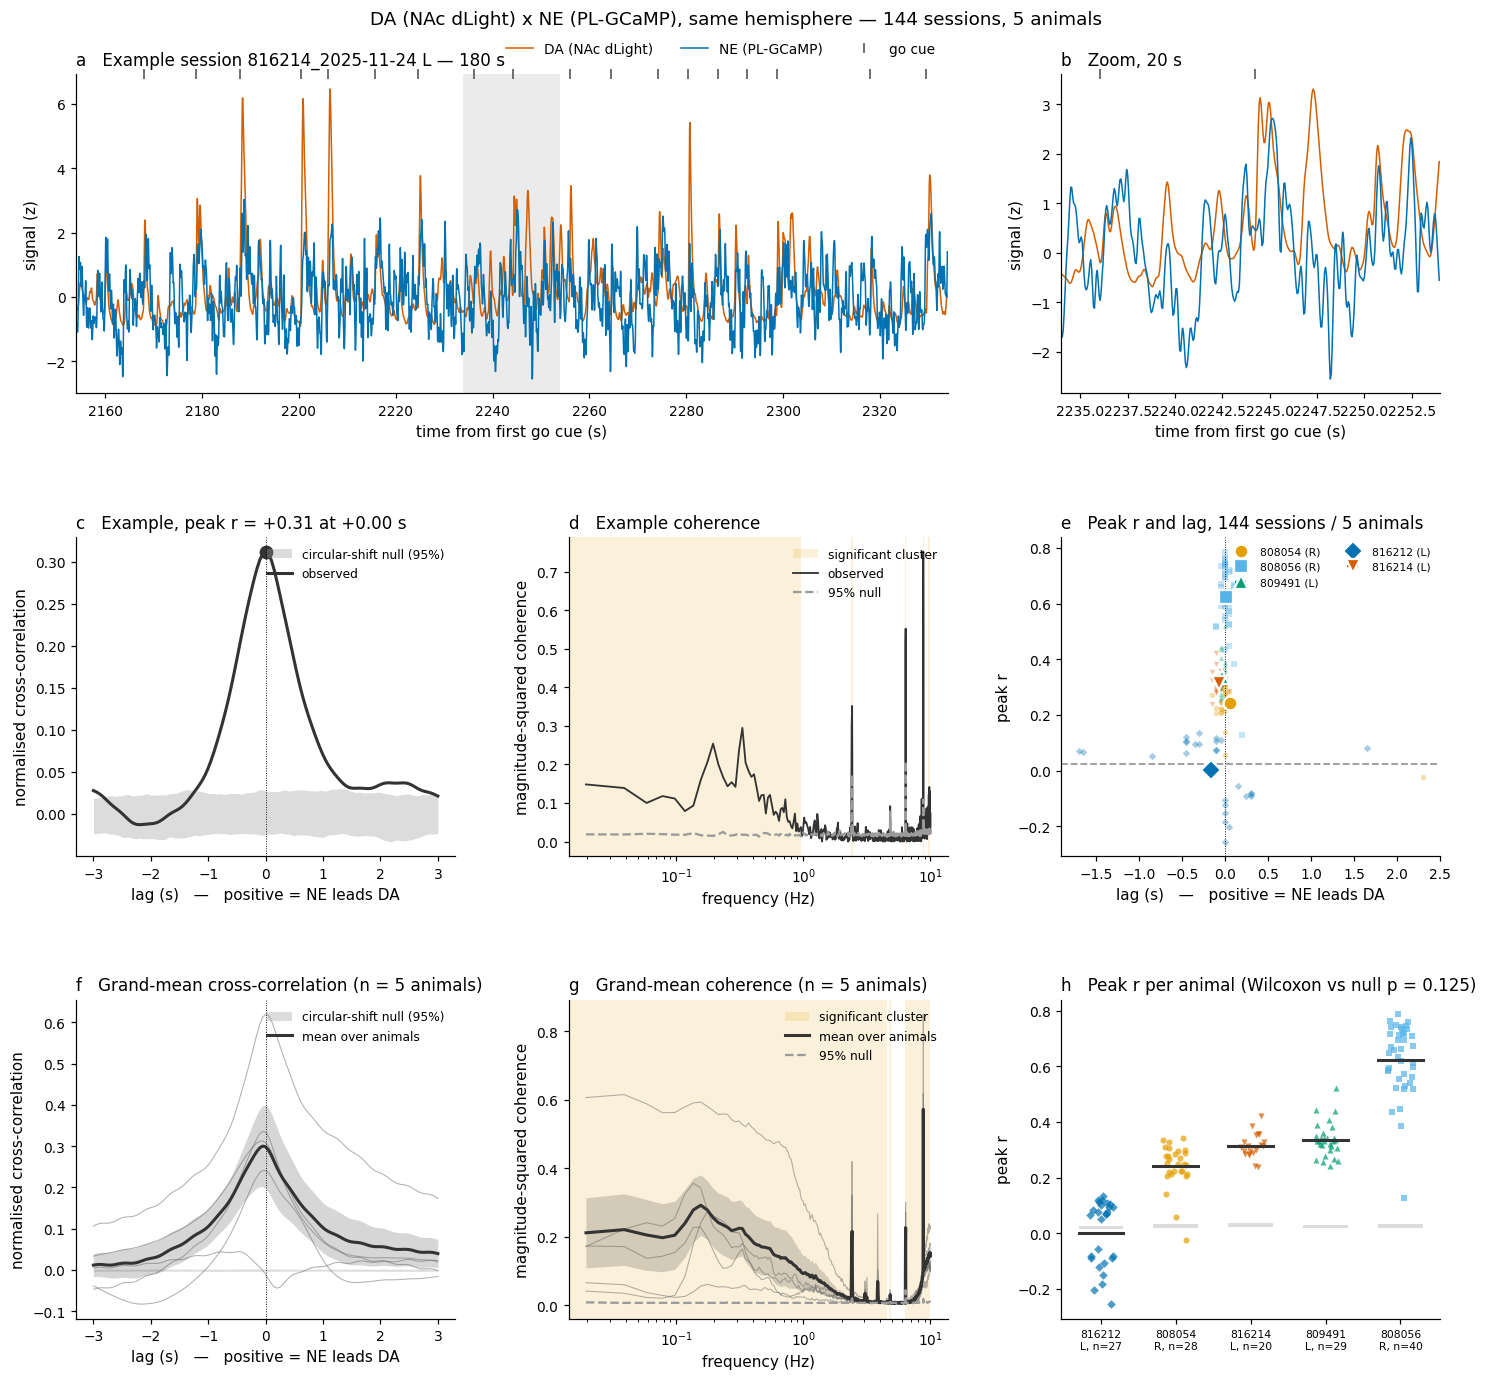

In [ ]:
fig = plt.figure(figsize=(16, 13))
gs = GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.3, top=0.93, bottom=0.06)

# a -- example traces
ax = fig.add_subplot(gs[0, :2])
plot_traces(ax, ex, win_a, shade=win_b)
ax.set_title("a   Example session %s — %.0f s" % (EX_TAG, EXAMPLE_WINDOW_S), loc="left")
ax.legend(loc="lower right", bbox_to_anchor=(1.0, 1.02), ncol=3, frameon=False)

# b -- zoom
ax = fig.add_subplot(gs[0, 2])
plot_traces(ax, ex, win_b)
ax.set_title("b   Zoom, %.0f s" % EXAMPLE_ZOOM_S, loc="left")

# c -- example cross-correlation
ax = fig.add_subplot(gs[1, 0])
lo_c, hi_c = np.percentile(ex["xcorr_null"], [2.5, 97.5], axis=0)
ax.fill_between(LAGS, lo_c, hi_c, color=NULL_COLOR, alpha=0.35, lw=0,
                label="circular-shift null (95%)")
ax.plot(LAGS, ex["xcorr"], color=GRAND_COLOR, lw=2, label="observed")
ax.plot(ex["peak_lag"], ex["peak_r"], "o", color=GRAND_COLOR, ms=8)
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel(LAG_XLABEL)
ax.set_ylabel("normalised cross-correlation")
ax.set_title("c   Example, peak r = %+.2f at %+.2f s" % (ex["peak_r"], ex["peak_lag"]),
             loc="left")
ax.legend(loc="upper left", fontsize=8)
style_ax(ax)

# d -- example coherence
ax = fig.add_subplot(gs[1, 1])
shade_clusters(ax, ex_clusters)
ax.semilogx(f_coh[1:], ex["coh"][1:], color=GRAND_COLOR, lw=1.2, label="observed")
ax.semilogx(f_coh[1:], ex_thr[1:], color=NULL_COLOR, lw=1.5, ls="--", label="95% null")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("magnitude-squared coherence")
ax.set_title("d   Example coherence", loc="left")
ax.legend(loc="upper right", fontsize=8)
style_ax(ax)

# e -- peak lag vs peak r, sessions and animals
ax = fig.add_subplot(gs[1, 2])
for subj in SUBJECTS:
    color, marker = ANIMAL_STYLE[subj]
    sub = df_sess[df_sess["subject"] == subj]
    ax.scatter(sub["peak_lag_s"], sub["peak_r"], s=12, color=color, marker=marker, alpha=0.35,
               lw=0)
    n = len(sub)
    ax.errorbar(sub["peak_lag_s"].mean(), sub["peak_r"].mean(),
                xerr=sub["peak_lag_s"].std(ddof=1) / np.sqrt(n) if n > 1 else 0,
                yerr=sub["peak_r"].std(ddof=1) / np.sqrt(n) if n > 1 else 0,
                fmt=marker, color=color, ms=9, mec="white", mew=1.5, elinewidth=1.5,
                capsize=0, label="%s (%s)" % (subj, SIDE[subj]))
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.axhline(df_sess["null_median"].mean(), color=NULL_COLOR, lw=1.2, ls="--")
ax.set_xlabel(LAG_XLABEL)
ax.set_ylabel("peak r")
ax.set_title("e   Peak r and lag, %d sessions / %d animals" % (len(sessions), N_ANIMALS),
             loc="left")
ax.legend(loc="upper right", fontsize=7, ncol=2)
style_ax(ax)

# f -- grand-mean cross-correlation
ax = fig.add_subplot(gs[2, 0])
ax.fill_between(LAGS, xc_null_lo, xc_null_hi, color=NULL_COLOR, alpha=0.35, lw=0,
                label="circular-shift null (95%)")
for c in xc_animal:
    ax.plot(LAGS, c, color=PALETTE["neutral"], lw=0.7, alpha=0.5)
ax.plot(LAGS, xc_mean, color=GRAND_COLOR, lw=2, label="mean over animals")
ax.fill_between(LAGS, xc_mean - xc_sem, xc_mean + xc_sem, color=GRAND_COLOR, alpha=0.2, lw=0)
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel(LAG_XLABEL)
ax.set_ylabel("normalised cross-correlation")
ax.set_title("f   Grand-mean cross-correlation (n = %d animals)" % N_ANIMALS, loc="left")
ax.legend(loc="upper right", fontsize=8)
style_ax(ax)

# g -- grand-mean coherence
ax = fig.add_subplot(gs[2, 1])
shade_clusters(ax, coh_clusters)
for c in coh_animal:
    ax.semilogx(f_coh[1:], c[1:], color=PALETTE["neutral"], lw=0.7, alpha=0.5)
ax.semilogx(f_coh[1:], coh_mean[1:], color=GRAND_COLOR, lw=2, label="mean over animals")
ax.fill_between(f_coh[1:], (coh_mean - coh_sem)[1:], (coh_mean + coh_sem)[1:],
                color=GRAND_COLOR, alpha=0.2, lw=0)
ax.semilogx(f_coh[1:], coh_thr[1:], color=NULL_COLOR, lw=1.5, ls="--", label="95% null")
ax.set_xlabel("frequency (Hz)")
ax.set_ylabel("magnitude-squared coherence")
ax.set_title("g   Grand-mean coherence (n = %d animals)" % N_ANIMALS, loc="left")
ax.legend(loc="upper right", fontsize=8)
style_ax(ax)

# h -- per-animal peak r
ax = fig.add_subplot(gs[2, 2])
animal_strip(ax, "peak_r", "null_median", "peak r")
p_r = df_tests.loc[0, "p"]
ax.set_title("h   Peak r per animal (Wilcoxon vs null p = %.3f)" % p_r, loc="left")

fig.suptitle("DA (NAc dLight) x NE (PL-GCaMP), same hemisphere — %d sessions, %d animals"
             % (len(sessions), N_ANIMALS), y=0.975)
save_fig(fig, "fip_04_fig1_da_ne_xcorr", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 7. Supplementary — band coherence, stability across days, and within the session

- **i** — mean coherence in `BAND_HZ` per animal, laid out like panel h.
- **j** — peak r across recording days. Each animal's first session is day 0. A trend here would
  mean the coupling changes with training or with fiber/sensor state, and the two cannot be told
  apart from these data.
- **k** — zero-lag correlation in `WIN_S`-s windows stepped by `WIN_STEP_S`, against time from the
  first go cue. Averaged over sessions within animal, then over animals, and drawn only where at
  least `MIN_ANIMALS_PER_WINDOW` animals contribute. Zero lag is used because the per-session
  peaks sit at or near 0 (section 3).

In [14]:
WIN_STARTS = np.arange(0.0, WIN_MAX_S - WIN_S + 1e-9, WIN_STEP_S)
n_win = int(round(WIN_S * FS))
for s in sessions:
    r_win = np.full(len(WIN_STARTS), np.nan)
    for i, w0 in enumerate(WIN_STARTS):
        a = int(round((w0 - s["t0"]) * FS))
        if a < 0 or a + n_win > len(s["da"]):
            continue
        r_win[i] = np.corrcoef(s["da"][a:a + n_win], s["ne"][a:a + n_win])[0, 1]
    s["r_win"] = r_win

win_mean, win_sem, win_animal = grand_mean([s["r_win"] for s in sessions])
win_n = np.sum(np.isfinite(win_animal), axis=0)
win_ok = win_n >= MIN_ANIMALS_PER_WINDOW
win_centres_min = (WIN_STARTS + WIN_S / 2.0) / 60.0

# Days since each animal's first session, from the date in session_id ('808054_2025-09-02').
dates = pd.to_datetime(df_sess["session"].str.split("_").str[1], errors="coerce")
df_sess["day"] = (dates - dates.groupby(df_sess["subject"]).transform("min")).dt.days
day_rho = pd.Series({subj: stats.spearmanr(g["day"], g["peak_r"]).statistic
                     if len(g) >= 3 else np.nan
                     for subj, g in df_sess.groupby("subject")}).reindex(SUBJECTS)
w_day = stats.wilcoxon(day_rho.dropna())
print("Spearman rho(day, peak r) within animal: %s"
      % ", ".join("%s %+.2f" % (k, v) for k, v in day_rho.items()))
print("across animals vs 0: Wilcoxon W=%.1f, p=%.4f" % (w_day.statistic, w_day.pvalue))

Spearman rho(day, peak r) within animal: 808054 -0.21, 808056 -0.68, 809491 -0.36, 816212 -0.44, 816214 +0.06
across animals vs 0: Wilcoxon W=1.0, p=0.1250


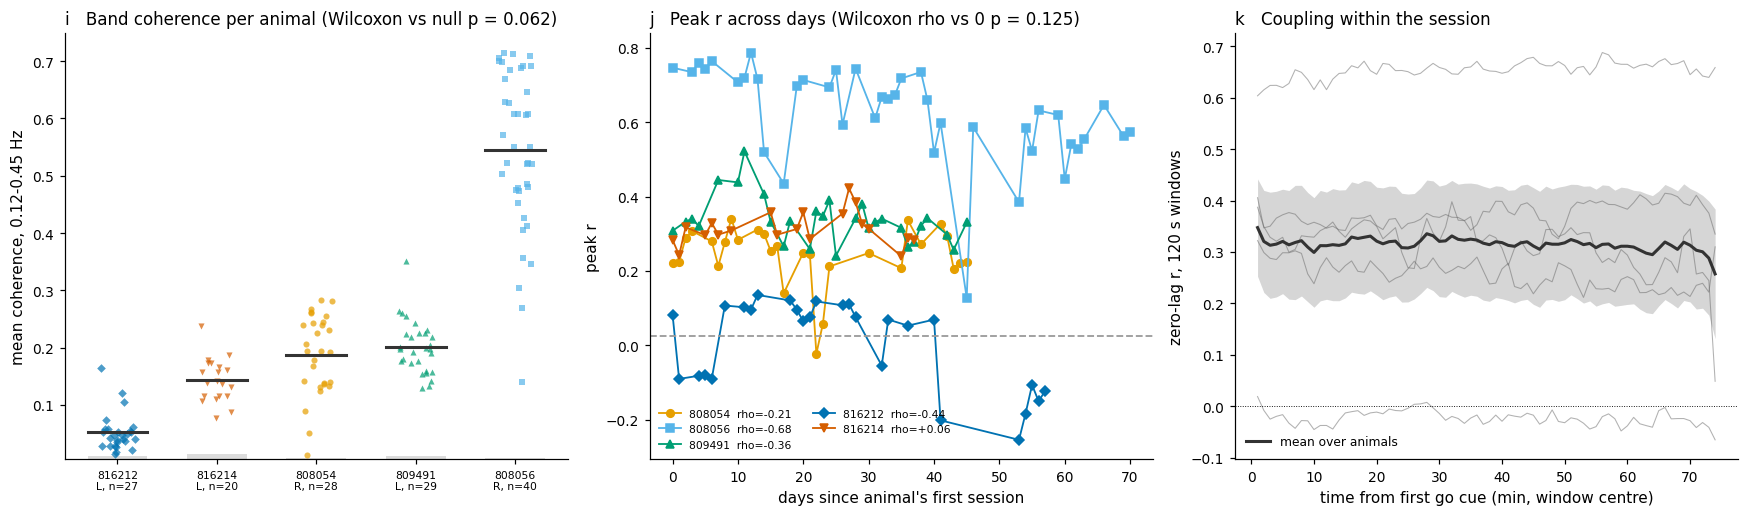

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
animal_strip(ax, "band_coh", "band_null_median", "mean coherence, %.2f-%.2f Hz" % BAND_HZ)
ax.set_title("i   Band coherence per animal (Wilcoxon vs null p = %.3f)"
             % df_tests.loc[2, "p"], loc="left")

ax = axes[1]
for subj in SUBJECTS:
    color, marker = ANIMAL_STYLE[subj]
    sub = df_sess[df_sess["subject"] == subj].sort_values("day")
    ax.plot(sub["day"], sub["peak_r"], color=color, marker=marker, ms=5, lw=1.2,
            label="%s  rho=%+.2f" % (subj, day_rho[subj]))
ax.axhline(df_sess["null_median"].mean(), color=NULL_COLOR, lw=1.2, ls="--")
ax.set_xlabel("days since animal's first session")
ax.set_ylabel("peak r")
ax.set_title("j   Peak r across days (Wilcoxon rho vs 0 p = %.3f)" % w_day.pvalue, loc="left")
ax.legend(fontsize=7, ncol=2)
style_ax(ax)

ax = axes[2]
for c in win_animal:
    ax.plot(win_centres_min, np.where(win_ok, c, np.nan), color=PALETTE["neutral"], lw=0.7,
            alpha=0.5)
ax.plot(win_centres_min[win_ok], win_mean[win_ok], color=GRAND_COLOR, lw=2,
        label="mean over animals")
ax.fill_between(win_centres_min[win_ok], (win_mean - win_sem)[win_ok],
                (win_mean + win_sem)[win_ok], color=GRAND_COLOR, alpha=0.2, lw=0)
ax.axhline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("time from first go cue (min, window centre)")
ax.set_ylabel("zero-lag r, %.0f s windows" % WIN_S)
ax.set_title("k   Coupling within the session", loc="left")
ax.legend(fontsize=8)
style_ax(ax)

fig.tight_layout()
save_fig(fig, "fip_04_fig2_da_ne_supplementary", fig_dir=FIG_DIR, save=SAVE_FIG)
plt.show()

## 8. What these measurements support

**Lag.** dLight and GCaMP have different rise and decay kinetics, so where the cross-correlation
peaks reflects both the indicators and the transmitters, and these data cannot separate the two
(`fip_03` §4 note). A peak lag describes the measured signals. It does not establish which
transmitter leads.

**What the two signals are.** NE here is axonal calcium in LC terminals in PL; DA is extracellular
dopamine at the NAc fiber, release and reuptake included. A correlation between them bounds how
tightly LC axonal activity and NAc DA concentration co-vary on the shared 2–8 s timescale.
Neither measurement is of the other transmitter's release.

**Scope.** One hemisphere per animal, and which hemisphere varies between animals, so side is
confounded with animal and is not tested. Intervals and tests are over animals; the bootstrap
resamples animals and then sessions within animal.

**Figure destination.** Figures go to `/root/capsule/scratch/figures/fip`, which a reproducible run
does not preserve. Copy anything headed for a paper figure to `/results`.